# 05 — Final results and figures

Turns `results/tables/04_multispectral_subset_comparison.csv` into the final small-multiples RMSE/R\u00b2-vs-band-count figure for all seven PROSPECT-D/SAIL parameters, and produces a side-by-side real-image comparison of multispectral-only vs. hyperspectral pigment/water-content retrieval on the same crop used in notebook 03.

This is the summary notebook — see notebooks 01-04 for the full pipeline and methodology.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
from src import tanager_io, prospect_inversion as pi, channel_selector as cs

## RMSE/R\u00b2 vs. band count, all seven parameters

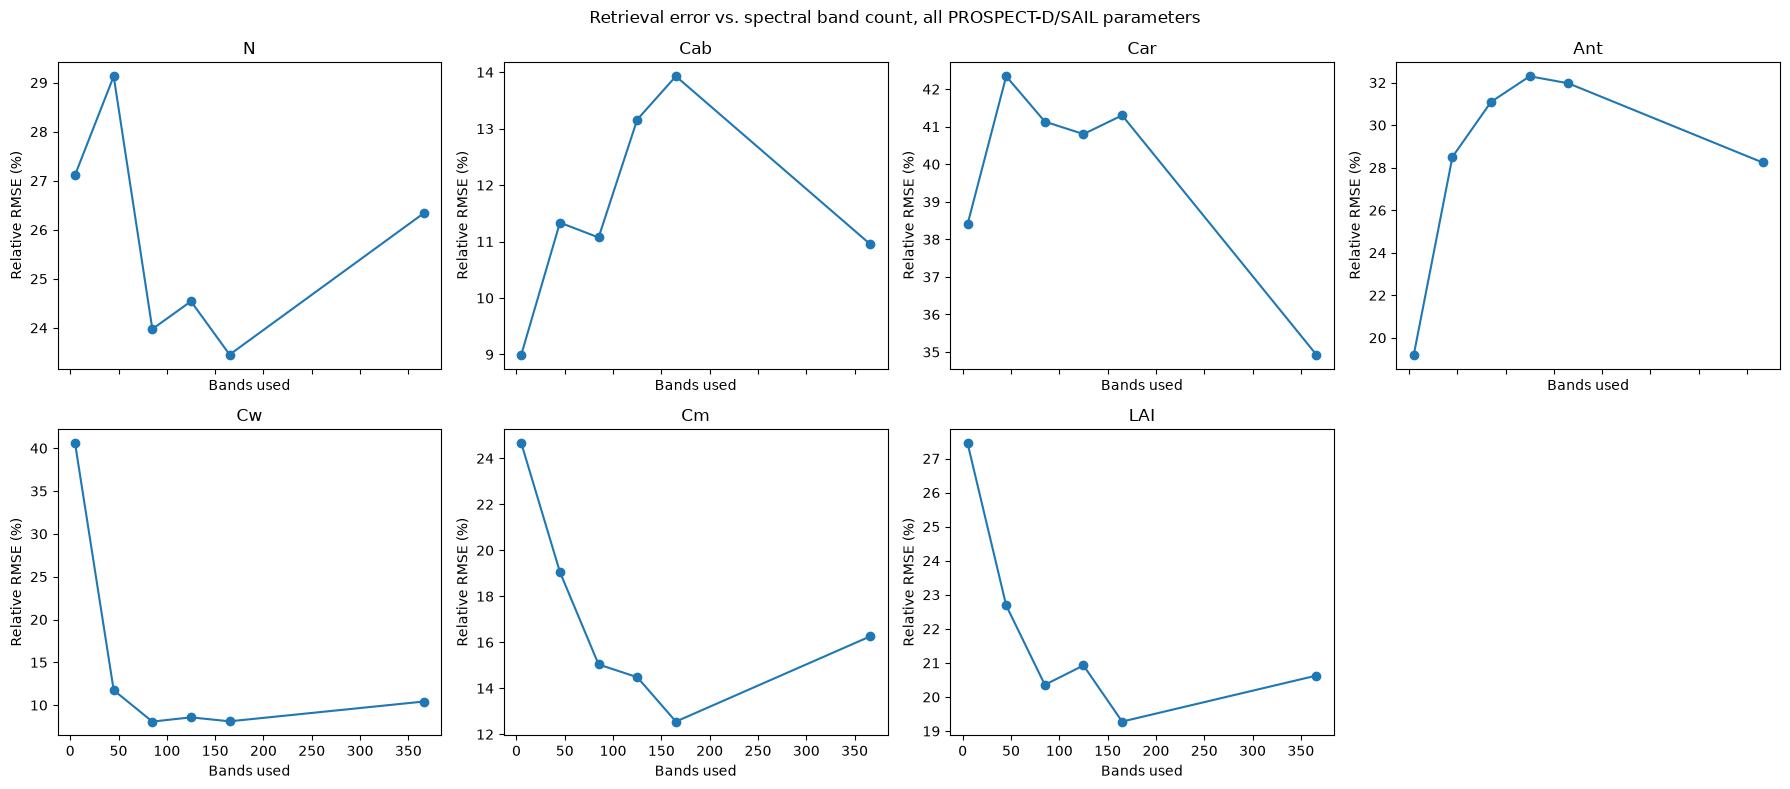

In [2]:
comparison = pd.read_csv("../results/tables/04_multispectral_subset_comparison.csv")
subset_labels = list(comparison["subset"].unique())
param_names = list(comparison["parameter"].unique())

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True)
for ax, param in zip(axes.flat, param_names):
    sub = comparison[comparison["parameter"] == param].set_index("subset").loc[subset_labels]
    ax.plot(sub["n_bands"], sub["relative_rmse_pct"], marker="o", color="C0")
    ax.set_title(param)
    ax.set_xlabel("Bands used")
    ax.set_ylabel("Relative RMSE (%)")
axes.flat[-1].axis("off")
plt.suptitle("Retrieval error vs. spectral band count, all PROSPECT-D/SAIL parameters")
plt.tight_layout()
plt.savefig("../results/figures/05_rmse_vs_bands_all_parameters.png", dpi=150)
plt.show()

## Summary table: hyperspectral vs. 5-band multispectral

In [3]:
summary = comparison[comparison["subset"].isin(["5-band multispectral (no SWIR)", "Full hyperspectral (valid bands)"])]
summary_pivot = summary.pivot(index="parameter", columns="subset", values="relative_rmse_pct")
summary_pivot["improvement_pct_points"] = (
    summary_pivot["5-band multispectral (no SWIR)"] - summary_pivot["Full hyperspectral (valid bands)"]
)
summary_pivot = summary_pivot.sort_values("improvement_pct_points", ascending=False)
summary_pivot.to_csv("../results/tables/05_final_summary.csv")
summary_pivot

subset,5-band multispectral (no SWIR),Full hyperspectral (valid bands),improvement_pct_points
parameter,,,
Cw,40.584293,10.422511,30.161783
Cm,24.656333,16.253635,8.402698
LAI,27.449436,20.627417,6.822018
Car,38.402303,34.931440,3.470863
N,27.117032,26.338315,0.778717
Cab,8.996675,10.955520,-1.958845
Ant,19.209309,28.245109,-9.035800


## Real-image comparison: multispectral-only vs. hyperspectral

Same reference LUT (seed 42) and same real-image crop as notebook 03, inverted twice: once restricted to the 5-band multispectral mask, once using the full valid-band hyperspectral mask. Cw is this project's headline result — the crop is dominated by forest/riparian vegetation, so absolute Cw values are illustrative rather than a crop-specific validation claim.

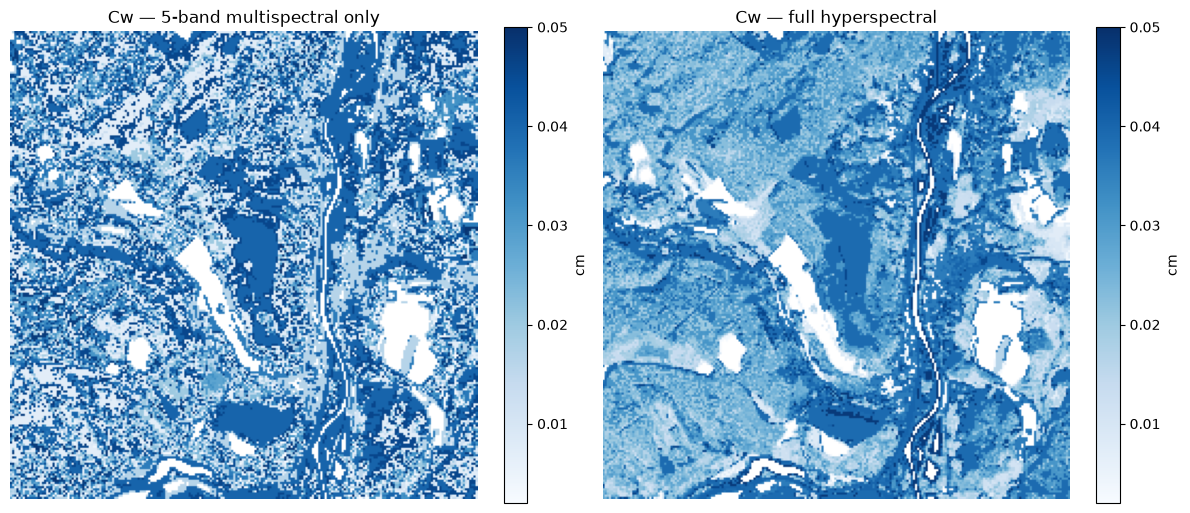

In [4]:
SCENE_SR_PATH = Path("../data/tanager_scene_01/scene_basic_sr.h5")
scene = tanager_io.load_surface_reflectance(SCENE_SR_PATH)
wavelengths = scene.wavelengths
reflectance = scene.cube.copy()
invalid_pixels = scene.cloud_mask | scene.cirrus_mask | scene.nodata_mask
reflectance[invalid_pixels] = np.nan
mean_sun_zenith = float(np.nanmean(scene.sun_zenith[~invalid_pixels]))

red_idx = int(np.argmin(np.abs(wavelengths - 650)))
nir_idx = int(np.argmin(np.abs(wavelengths - 840)))
ndvi = (reflectance[:, :, nir_idx] - reflectance[:, :, red_idx]) / (
    reflectance[:, :, nir_idx] + reflectance[:, :, red_idx] + 1e-6
)
vegetation_mask = (ndvi > 0.3) & ~invalid_pixels
valid_bands = cs.valid_band_mask(wavelengths)
multispectral_mask = np.zeros(len(wavelengths), dtype=bool)
multispectral_mask[list(cs.nearest_band_indices(wavelengths, cs.MULTISPECTRAL_BANDS_NM).values())] = True

reference_lut = pi.generate_lut(n_samples=8000, wavelengths=wavelengths, seed=42, tts=mean_sun_zenith)
param_names_lut = reference_lut["parameter_names"]
cw_idx = param_names_lut.index("Cw")

# Same crop-selection logic as notebook 03
CROP_SIZE, STRIDE = 220, 40
n_rows, n_cols = vegetation_mask.shape
best_window, best_density = None, -1.0
for r0 in range(0, n_rows - CROP_SIZE, STRIDE):
    for c0 in range(0, n_cols - CROP_SIZE, STRIDE):
        density = vegetation_mask[r0:r0 + CROP_SIZE, c0:c0 + CROP_SIZE].mean()
        if density > best_density:
            best_density, best_window = density, (r0, c0)
r0, c0 = best_window
crop_mask = vegetation_mask[r0:r0 + CROP_SIZE, c0:c0 + CROP_SIZE]
crop_reflectance = reflectance[r0:r0 + CROP_SIZE, c0:c0 + CROP_SIZE, :]
crop_rows, crop_cols = np.where(crop_mask)
crop_spectra = crop_reflectance[crop_rows, crop_cols, :]

def invert_chunked(spectra, mask, chunk=8000):
    out = []
    for start in range(0, len(spectra), chunk):
        out.append(pi.invert_lut_batch(spectra[start:start + chunk], reference_lut, wavelength_mask=mask))
    return np.concatenate(out, axis=0)

cw_multispectral = invert_chunked(crop_spectra, multispectral_mask)[:, cw_idx]
cw_hyperspectral = invert_chunked(crop_spectra, valid_bands)[:, cw_idx]

cw_map_ms = np.full(crop_mask.shape, np.nan)
cw_map_hs = np.full(crop_mask.shape, np.nan)
cw_map_ms[crop_rows, crop_cols] = cw_multispectral
cw_map_hs[crop_rows, crop_cols] = cw_hyperspectral

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
im0 = axes[0].imshow(cw_map_ms, cmap="Blues", vmin=0.002, vmax=0.05)
axes[0].set_title("Cw — 5-band multispectral only")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, label="cm")
im1 = axes[1].imshow(cw_map_hs, cmap="Blues", vmin=0.002, vmax=0.05)
axes[1].set_title("Cw — full hyperspectral")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, label="cm")
plt.tight_layout()
plt.savefig("../results/figures/05_cw_multispectral_vs_hyperspectral_map.png", dpi=150)
plt.show()

## Conclusion

See the README "Results" section for the written summary of these findings, cross-referenced against `results/tables/04_multispectral_subset_comparison.csv` and `results/tables/05_final_summary.csv`.